In [210]:
import pandas as pd

In [211]:
df = pd.read_csv("salary.csv")
df.head()

,Timestamp,Age,Industry,Job title,Context,Salary,Compensation,Currency,Other currency,Salary context,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [212]:
df["Salary"] = df["Salary"].replace(',','',regex=True).astype(int)

In [213]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27989 entries, 0 to 27988
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           27989 non-null  str    
 1   Age                                 27989 non-null  str    
 2   Industry                            27917 non-null  str    
 3   Job title                           27989 non-null  str    
 4   Context                             7240 non-null   str    
 5   Salary                              27989 non-null  int64  
 6   Compensation                        20719 non-null  float64
 7   Currency                            27989 non-null  str    
 8   Other currency                      197 non-null    str    
 9   Salary context                      3034 non-null   str    
 10  Country                             27989 non-null  str    
 11  State                               22993 non-null  

In [214]:
df["Compensation"].isna().sum()

np.int64(7270)

In [215]:
for col in df.columns:
    print(f"{col} column: {df[col].isna().sum()} null values")

Timestamp column: 0 null values
Age column: 0 null values
Industry column: 72 null values
Job title column: 0 null values
Context column: 20749 null values
Salary column: 0 null values
Compensation column: 7270 null values
Currency column: 0 null values
Other currency column: 27792 null values
Salary context column: 24955 null values
Country column: 0 null values
State column: 4996 null values
City column: 80 null values
Overall years of experience column: 0 null values
Years of experience in current job column: 0 null values
Education level column: 216 null values
Gender column: 167 null values
Race column: 172 null values


In [216]:
df.drop(columns=["Context","Other currency","Salary context"],inplace=True)

In [217]:
df.head()

,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,54600,4000.0,GBP,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [218]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
imputer = SimpleImputer(strategy="mean")

In [219]:
numeric_cols = df.select_dtypes(include=('int','float')).columns.tolist()
categorical_cols = df.select_dtypes(exclude=('int','float')).columns.tolist()

In [220]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',SimpleImputer(strategy='mean'),numeric_cols),
        ('cat',SimpleImputer(strategy='most_frequent'),categorical_cols),
    ])

In [221]:
df_imputed = pd.DataFrame(preprocessor.fit_transform(df), columns=numeric_cols+categorical_cols)
df_imputed[numeric_cols] = df_imputed[numeric_cols].astype('float')

In [222]:
df_imputed[numeric_cols]

,Salary,Compensation
0,55000.0,0.000000
1,54600.0,4000.000000
2,34000.0,18191.274482
3,62000.0,3000.000000
4,60000.0,7000.000000
...,...,...
27984,28600.0,18191.274482
27985,125000.0,12500.000000
27986,72000.0,5000.000000
27987,30000.0,10000.000000


In [223]:
df_imputed["Salary"].describe()

count    2.798900e+04
mean     1.471626e+05
std      5.414698e+06
min      0.000000e+00
25%      5.400000e+04
50%      7.500000e+04
75%      1.100000e+05
max      8.700000e+08
Name: Salary, dtype: float64

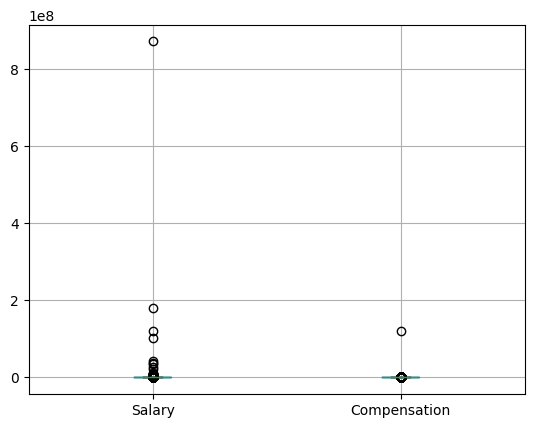

In [224]:
import matplotlib.pyplot as plt

# Boxplot to visualize outliers
df_imputed.boxplot(column=numeric_cols)
plt.show()

In [225]:
def remove_outliers_iqr(df, numerical_cols):
    """Remove outliers using Interquartile Range"""
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]
    
    return df

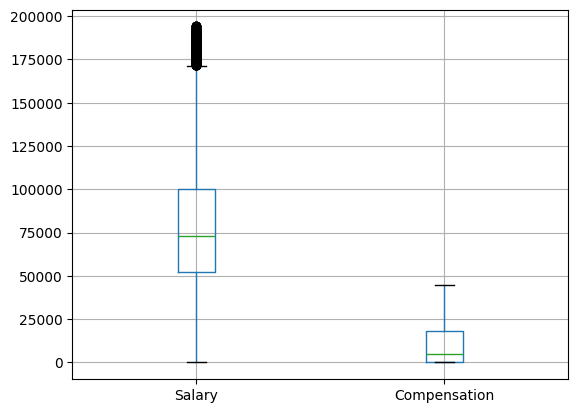

In [ ]:
df_imputed= remove_outliers_iqr(df_imputed,numeric_cols)
df_imputed = df_imputed[(df_imputed["Salary"]!=0)]
df_imputed.boxplot(column=numeric_cols)
plt.show()

In [230]:
for col in categorical_cols:
    if col != "Timestamp":
        print(f"{col} unique values: {df_imputed[col].unique()}")

Age unique values: <StringArray>
['25-34', '45-54', '35-44', '18-24', '65 or over', '55-64', 'under 18']
Length: 7, dtype: str
Industry unique values: <StringArray>
[  'Education (Higher Education)',              'Computing or Tech',
  'Accounting, Banking & Finance',                     'Nonprofits',
                     'Publishing',  'Education (Primary/Secondary)',
                            'Law',                    'Health care',
 'Utilities & Telecommunications',         'Business or Consulting',
 ...
         'Environmental science ',         'User Experience Design',
                      'Fast food',         'Hardware Manufacturing',
          'Real Estate / Housing',                 'Research / Gov',
                        'Biology',              'Undergrad student',
          'Concrete Construction',                       'Plumbing']
Length: 1175, dtype: str
Job title unique values: <StringArray>
[      'Research and Instruction Librarian',
 'Change & Internal Communicati